In [5]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────

import numpy as np                 # numerical operations
import pandas as pd                # dataset handling
import matplotlib.pyplot as plt    # plotting graphs

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
# ─────────────────────────────────────────────
# PERSONALIZED PARAMETERS
# ─────────────────────────────────────────────

ROLL = "102317087"

digits = [int(d) for d in ROLL]

# WHY: number of past values model sees
window_size = (sum(digits)) % 10 + 8   # = 17

# WHY: how many future values to predict
prediction_horizon = (int(ROLL[-2:])) % 3 + 1   # = 1

# WHY: model memory size
hidden_size = (int(ROLL[:3])) % 16 + 8   # = 14

print("Window Size:", window_size)
print("Prediction Horizon:", prediction_horizon)
print("Hidden Size:", hidden_size)
print("Model: Custom GRU (ODD roll number)")

Window Size: 17
Prediction Horizon: 1
Hidden Size: 14
Model: Custom GRU (ODD roll number)


In [7]:
# ─────────────────────────────────────────────
# WINDOWING
# ─────────────────────────────────────────────

def create_windows(data, window_size, horizon):
    """
    WHY:
    Convert time-series → supervised learning

    Example:
    [10,20,30,40]

    window=3 → X=[10,20,30], y=[40]
    """

    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):

        # past values
        X.append(data[i:i+window_size])

        # next value
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

In [8]:
# ─────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────

# Put this file in same folder
df = pd.read_csv("Electric_Production.csv")

# Rename columns safely
df.columns = ["Date", "Value"]

# Take only values
data = df["Value"].values.reshape(-1, 1)

In [9]:
# ─────────────────────────────────────────────
# NORMALIZATION
# ─────────────────────────────────────────────

# WHY: neural networks prefer small scaled values
scaler = MinMaxScaler()
data = scaler.fit_transform(data).flatten()

In [10]:
# ─────────────────────────────────────────────
# TRAIN-TEST SPLIT
# ─────────────────────────────────────────────

# WHY: time-series must keep order (no shuffle)
split = int(0.8 * len(data))

train_data = data[:split]
test_data  = data[split:]

In [11]:
# ─────────────────────────────────────────────
# DATA PREPARATION
# ─────────────────────────────────────────────

def prepare_data(data, window):

    X, y = create_windows(data, window, prediction_horizon)

    # Convert to tensor
    # shape → (batch, sequence, features)
    X = torch.FloatTensor(X).unsqueeze(-1)
    y = torch.FloatTensor(y)

    return DataLoader(TensorDataset(X, y), batch_size=32, shuffle=False)

In [12]:
class MLP(nn.Module):

    def __init__(self, input_size):   # ← dynamic input
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
# ─────────────────────────────────────────────
# CUSTOM GRU MODEL
# ─────────────────────────────────────────────

class CustomGRU(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden_size = hidden_size

        # Gates
        self.Wz = nn.Linear(1 + hidden_size, hidden_size)  # update gate
        self.Wr = nn.Linear(1 + hidden_size, hidden_size)  # reset gate
        self.Wh = nn.Linear(1 + hidden_size, hidden_size)  # candidate

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):

        batch_size = x.size(0)

        # initial memory
        h = torch.zeros(batch_size, hidden_size)

        for t in range(x.size(1)):

            # combine input + memory
            combined = torch.cat([x[:, t, :], h], dim=1)

            # update gate
            z = torch.sigmoid(self.Wz(combined))

            # reset gate
            r = torch.sigmoid(self.Wr(combined))

            # candidate memory
            combined_r = torch.cat([x[:, t, :], r * h], dim=1)
            h_new = torch.tanh(self.Wh(combined_r))

            # final memory update
            h = (1 - z) * h + z * h_new

        return self.fc(h)

In [14]:
# ─────────────────────────────────────────────
# LSTM MODEL (PREBUILT)
# ─────────────────────────────────────────────

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [25]:
# ─────────────────────────────────────────────
# TRANSFORMER MODEL
# ─────────────────────────────────────────────

class TransformerModel(nn.Module):
    """
    Improved Transformer for time-series
    """

    def __init__(self, input_size, hidden_size, horizon, seq_len):
        super().__init__()

        # Project input → higher dimension
        self.input_proj = nn.Linear(input_size, hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=2,
            dim_feedforward=hidden_size * 4,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        #  CHANGE: use LAST TIME STEP (important)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):

        # Step 1: project input
        x = self.input_proj(x)

        # Step 2: transformer
        x = self.transformer(x)

        # IMPORTANT FIX:
        # Take last time step instead of flattening
        x = x[:, -1, :]

        return self.fc(x)

In [27]:
# ─────────────────────────────────────────────
# TRAIN FUNCTION
# ─────────────────────────────────────────────

def train_model(model, loader):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(10):

        total_loss = 0

        for X, y in loader:

            optimizer.zero_grad()

            pred = model(X)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

    return losses

In [29]:
# ─────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────

def evaluate(model, loader):

    preds, actual = [], []

    with torch.no_grad():
        for X, y in loader:
            p = model(X).numpy()
            preds.extend(p)
            actual.extend(y.numpy())

    preds = np.array(preds)
    actual = np.array(actual)

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mse)

    return preds, actual, mse, mae, rmse

In [31]:
# ─────────────────────────────────────────────
# RUN EXPERIMENT
# ─────────────────────────────────────────────

def run(window):

    print("\nRunning for window:", window)

    train_loader = prepare_data(train_data, window)
    test_loader  = prepare_data(test_data, window)

    models = {
        "MLP": MLP(window),
        "GRU": CustomGRU(),
        "LSTM": LSTMModel(),
        "Transformer": TransformerModel(1, hidden_size, prediction_horizon, window)
    }

    for name, model in models.items():

        print("\nTraining:", name)

        losses = train_model(model, train_loader)

        preds, actual, mse, mae, rmse = evaluate(model, test_loader)

        print(f"{name} → MSE:{mse:.4f}, MAE:{mae:.4f}, RMSE:{rmse:.4f}")

        plt.plot(losses)
        plt.title(name + " Loss")
        plt.show()

        plt.plot(actual[:200], label="Actual")
        plt.plot(preds[:200], label="Predicted")
        plt.legend()
        plt.title(name)
        plt.show()


Running for window: 8

Training: MLP
Epoch 1: Loss = 0.2767
Epoch 2: Loss = 0.2221
Epoch 3: Loss = 0.1763
Epoch 4: Loss = 0.1379
Epoch 5: Loss = 0.1062
Epoch 6: Loss = 0.0804
Epoch 7: Loss = 0.0599
Epoch 8: Loss = 0.0442
Epoch 9: Loss = 0.0326
Epoch 10: Loss = 0.0245
MLP → MSE:0.0405, MAE:0.1566, RMSE:0.2012


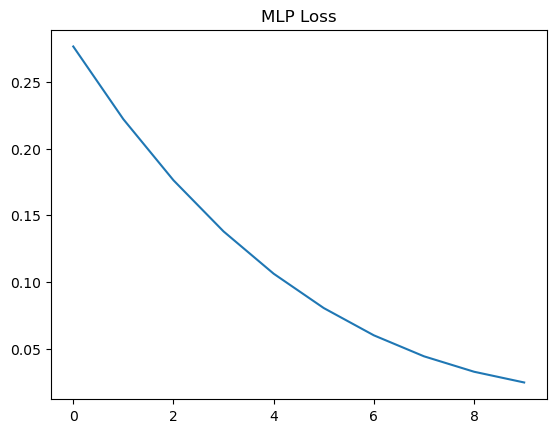

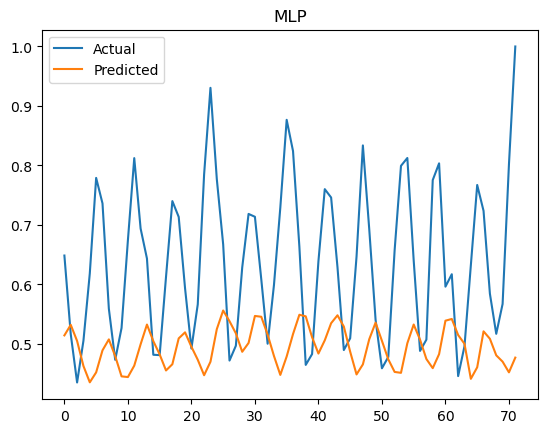


Training: GRU
Epoch 1: Loss = 0.4541
Epoch 2: Loss = 0.3587
Epoch 3: Loss = 0.2763
Epoch 4: Loss = 0.2048
Epoch 5: Loss = 0.1438
Epoch 6: Loss = 0.0941
Epoch 7: Loss = 0.0578
Epoch 8: Loss = 0.0366
Epoch 9: Loss = 0.0291
Epoch 10: Loss = 0.0293
GRU → MSE:0.0438, MAE:0.1660, RMSE:0.2092


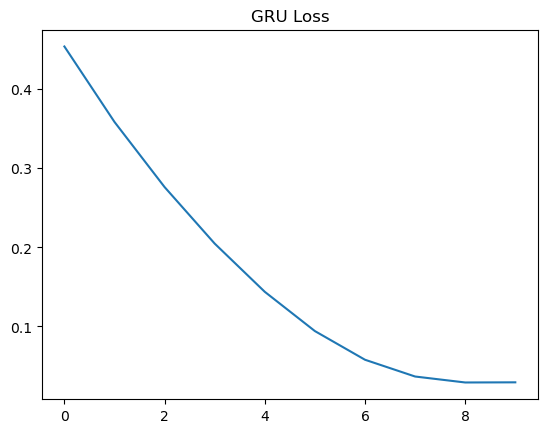

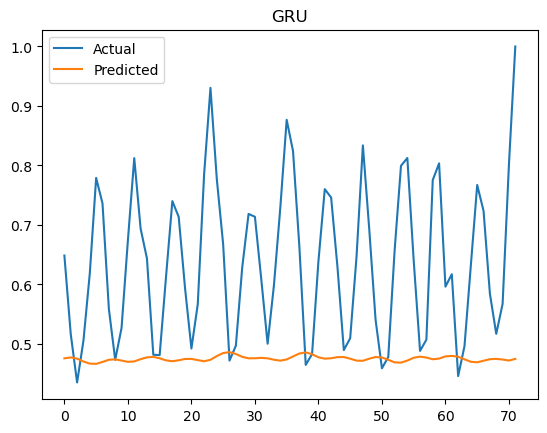


Training: LSTM
Epoch 1: Loss = 0.0487
Epoch 2: Loss = 0.0389
Epoch 3: Loss = 0.0340
Epoch 4: Loss = 0.0322
Epoch 5: Loss = 0.0319
Epoch 6: Loss = 0.0318
Epoch 7: Loss = 0.0316
Epoch 8: Loss = 0.0311
Epoch 9: Loss = 0.0305
Epoch 10: Loss = 0.0298
LSTM → MSE:0.0449, MAE:0.1695, RMSE:0.2118


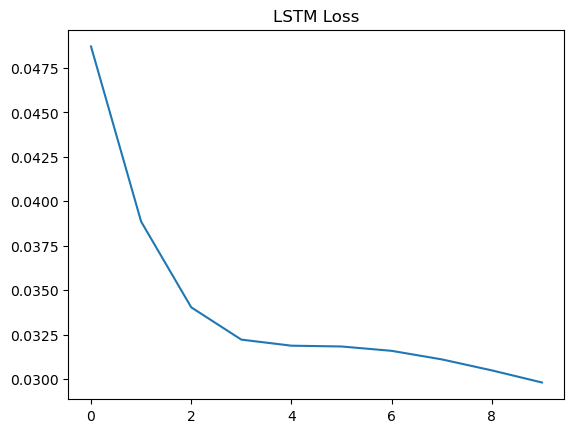

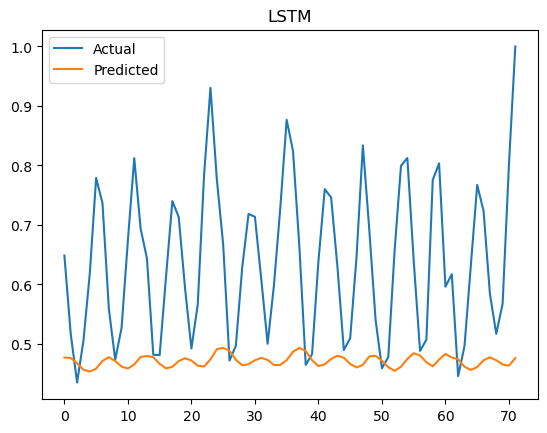


Training: Transformer
Epoch 1: Loss = 0.1182
Epoch 2: Loss = 0.0580
Epoch 3: Loss = 0.0318
Epoch 4: Loss = 0.0157
Epoch 5: Loss = 0.0163
Epoch 6: Loss = 0.0143
Epoch 7: Loss = 0.0148
Epoch 8: Loss = 0.0131
Epoch 9: Loss = 0.0148
Epoch 10: Loss = 0.0138
Transformer → MSE:0.0175, MAE:0.1110, RMSE:0.1321


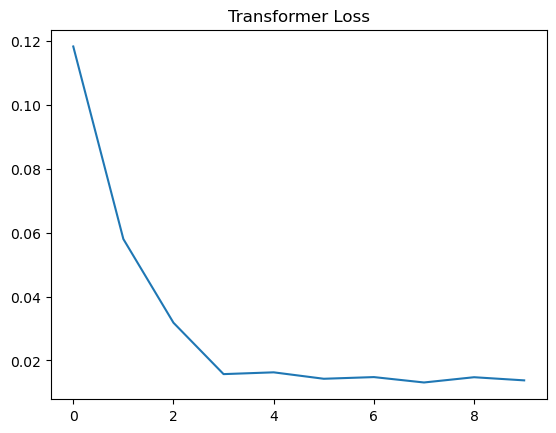

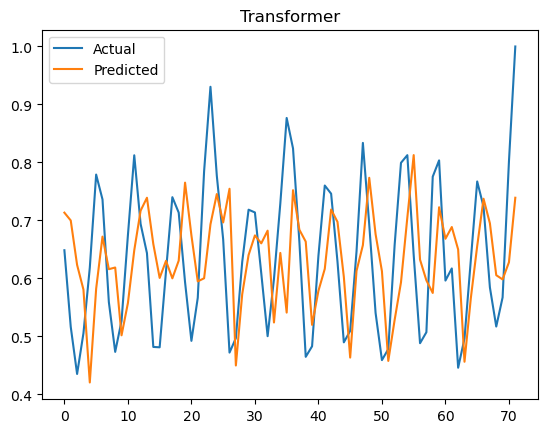


Running for window: 17

Training: MLP
Epoch 1: Loss = 0.4031
Epoch 2: Loss = 0.2763
Epoch 3: Loss = 0.1819
Epoch 4: Loss = 0.1141
Epoch 5: Loss = 0.0679
Epoch 6: Loss = 0.0393
Epoch 7: Loss = 0.0241
Epoch 8: Loss = 0.0177
Epoch 9: Loss = 0.0157
Epoch 10: Loss = 0.0152
MLP → MSE:0.0232, MAE:0.1297, RMSE:0.1522


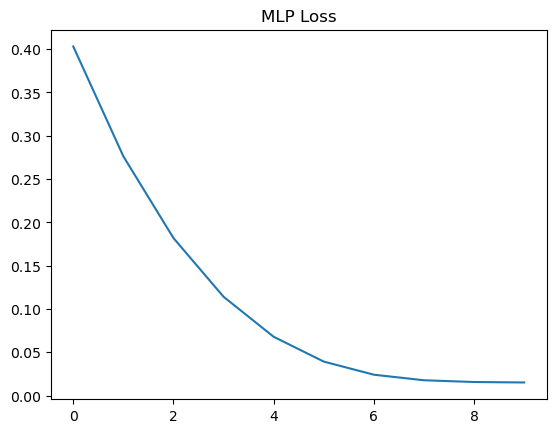

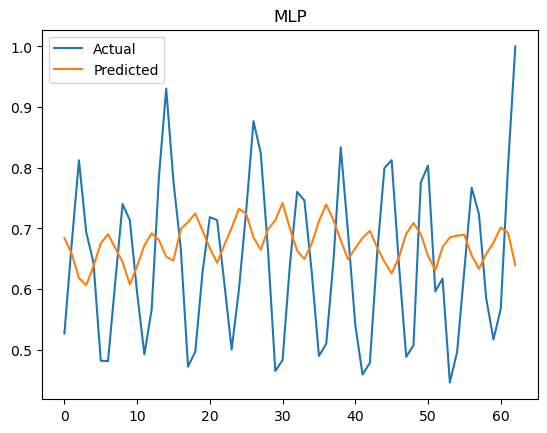


Training: GRU
Epoch 1: Loss = 0.0652
Epoch 2: Loss = 0.0511
Epoch 3: Loss = 0.0423
Epoch 4: Loss = 0.0381
Epoch 5: Loss = 0.0367
Epoch 6: Loss = 0.0364
Epoch 7: Loss = 0.0361
Epoch 8: Loss = 0.0354
Epoch 9: Loss = 0.0345
Epoch 10: Loss = 0.0335
GRU → MSE:0.0501, MAE:0.1827, RMSE:0.2239


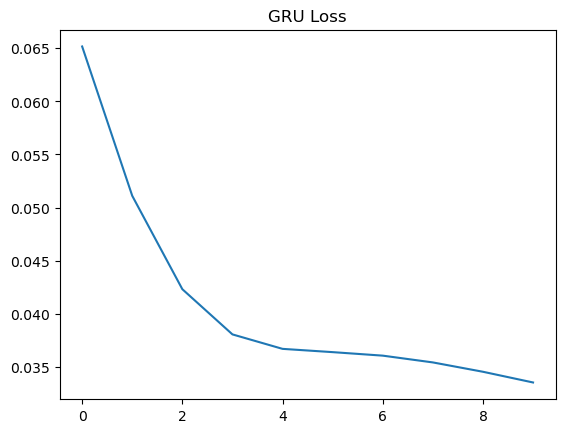

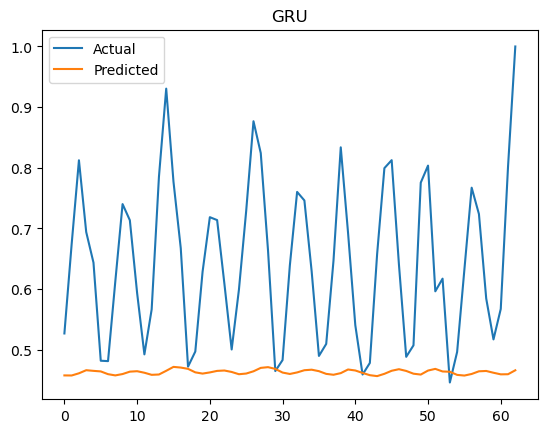


Training: LSTM
Epoch 1: Loss = 0.1607
Epoch 2: Loss = 0.1219
Epoch 3: Loss = 0.0930
Epoch 4: Loss = 0.0701
Epoch 5: Loss = 0.0519
Epoch 6: Loss = 0.0387
Epoch 7: Loss = 0.0314
Epoch 8: Loss = 0.0295
Epoch 9: Loss = 0.0303
Epoch 10: Loss = 0.0309
LSTM → MSE:0.0419, MAE:0.1621, RMSE:0.2047


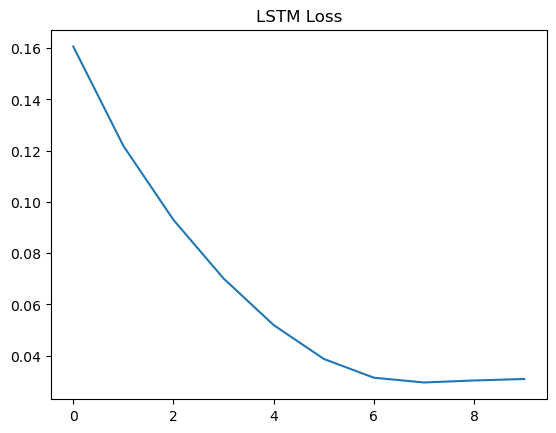

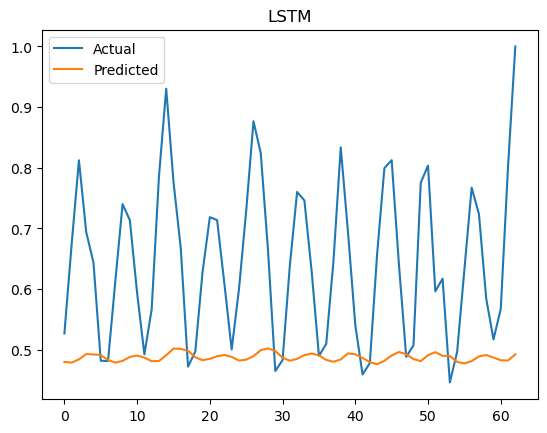


Training: Transformer
Epoch 1: Loss = 0.1452
Epoch 2: Loss = 0.0421
Epoch 3: Loss = 0.0307
Epoch 4: Loss = 0.0342
Epoch 5: Loss = 0.0294
Epoch 6: Loss = 0.0192
Epoch 7: Loss = 0.0188
Epoch 8: Loss = 0.0183
Epoch 9: Loss = 0.0181
Epoch 10: Loss = 0.0181
Transformer → MSE:0.0187, MAE:0.1077, RMSE:0.1368


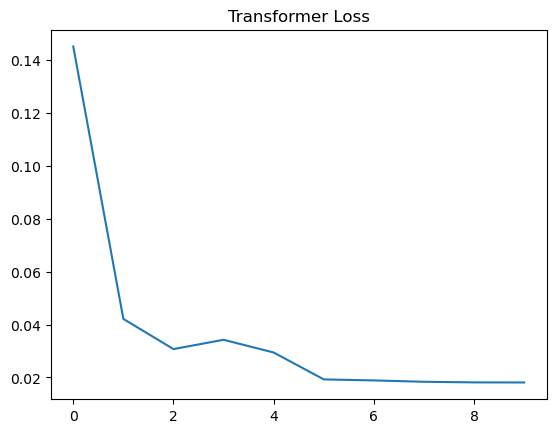

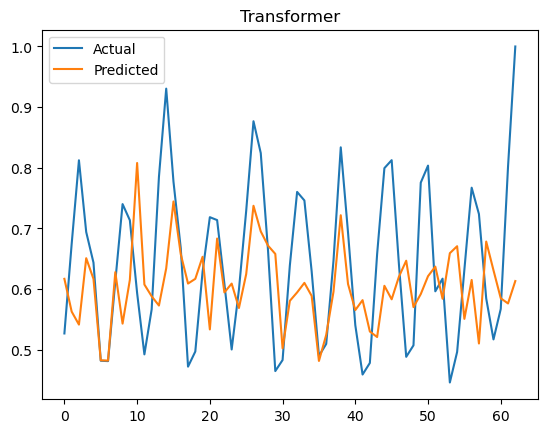


Running for window: 34

Training: MLP
Epoch 1: Loss = 0.1995
Epoch 2: Loss = 0.1082
Epoch 3: Loss = 0.0492
Epoch 4: Loss = 0.0193
Epoch 5: Loss = 0.0108
Epoch 6: Loss = 0.0108
Epoch 7: Loss = 0.0109
Epoch 8: Loss = 0.0102
Epoch 9: Loss = 0.0097
Epoch 10: Loss = 0.0095
MLP → MSE:0.0161, MAE:0.1079, RMSE:0.1268


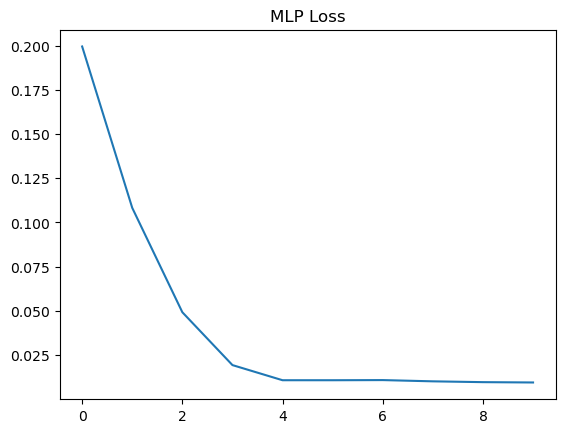

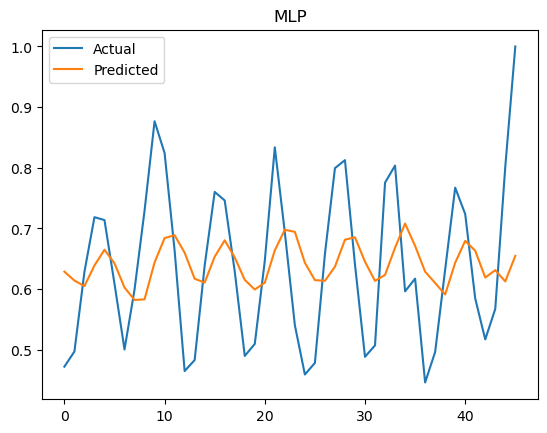


Training: GRU
Epoch 1: Loss = 0.6666
Epoch 2: Loss = 0.5700
Epoch 3: Loss = 0.4810
Epoch 4: Loss = 0.3969
Epoch 5: Loss = 0.3164
Epoch 6: Loss = 0.2391
Epoch 7: Loss = 0.1659
Epoch 8: Loss = 0.0997
Epoch 9: Loss = 0.0471
Epoch 10: Loss = 0.0185
GRU → MSE:0.0338, MAE:0.1435, RMSE:0.1840


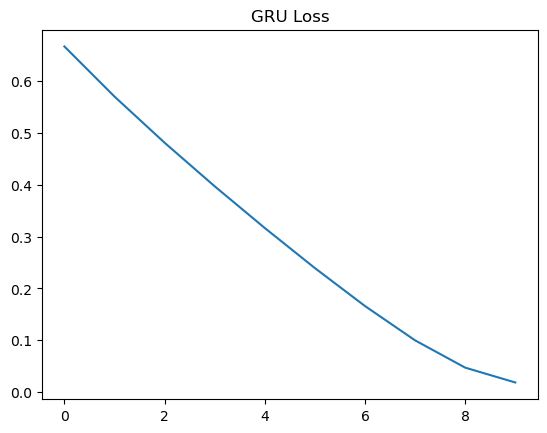

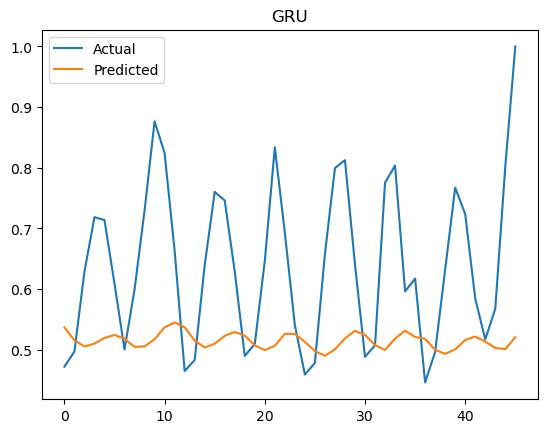


Training: LSTM
Epoch 1: Loss = 0.3423
Epoch 2: Loss = 0.2951
Epoch 3: Loss = 0.2506
Epoch 4: Loss = 0.2062
Epoch 5: Loss = 0.1597
Epoch 6: Loss = 0.1091
Epoch 7: Loss = 0.0569
Epoch 8: Loss = 0.0198
Epoch 9: Loss = 0.0220
Epoch 10: Loss = 0.0270
LSTM → MSE:0.0319, MAE:0.1409, RMSE:0.1785


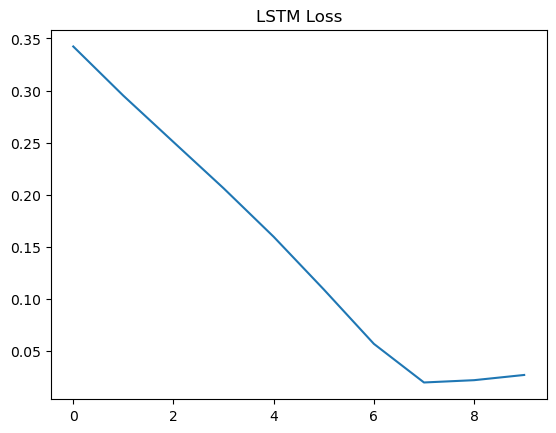

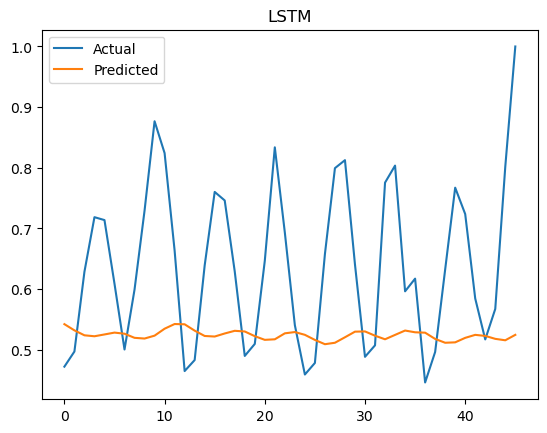


Training: Transformer
Epoch 1: Loss = 0.1951
Epoch 2: Loss = 0.3415
Epoch 3: Loss = 0.1461
Epoch 4: Loss = 0.0868
Epoch 5: Loss = 0.0365
Epoch 6: Loss = 0.0412
Epoch 7: Loss = 0.0393
Epoch 8: Loss = 0.0314
Epoch 9: Loss = 0.0252
Epoch 10: Loss = 0.0213
Transformer → MSE:0.0268, MAE:0.1304, RMSE:0.1638


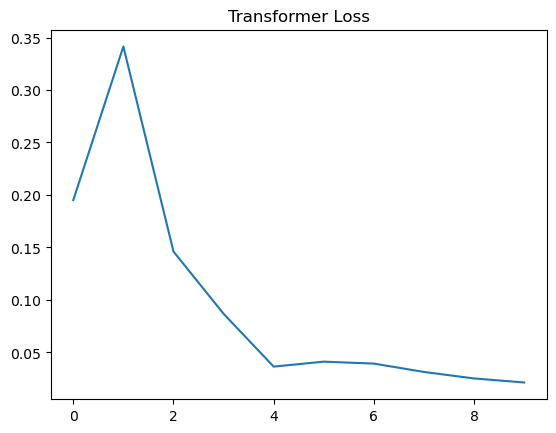

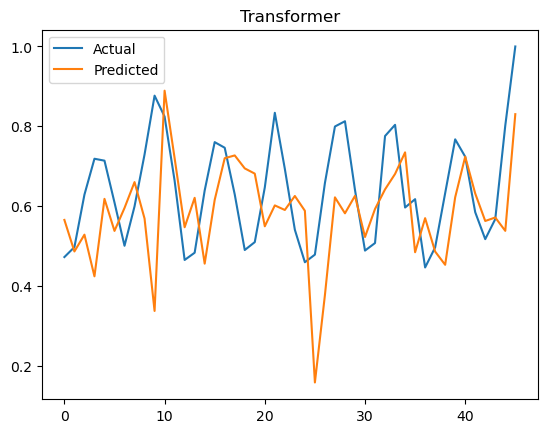

In [33]:
# ─────────────────────────────────────────────
# ABLATION STUDY
# ─────────────────────────────────────────────

# WHY:
# change window size → observe effect

windows = [
    window_size // 2,   # small window
    window_size,        # original
    window_size * 2     # large window
]

for w in windows:
    run(w)


Training: MLP
Epoch 1: Loss = 0.1149
Epoch 2: Loss = 0.0765
Epoch 3: Loss = 0.0483
Epoch 4: Loss = 0.0298
Epoch 5: Loss = 0.0201
Epoch 6: Loss = 0.0168
Epoch 7: Loss = 0.0161
Epoch 8: Loss = 0.0146
Epoch 9: Loss = 0.0136
Epoch 10: Loss = 0.0123

Training: GRU
Epoch 1: Loss = 0.3568
Epoch 2: Loss = 0.2632
Epoch 3: Loss = 0.1887
Epoch 4: Loss = 0.1296
Epoch 5: Loss = 0.0842
Epoch 6: Loss = 0.0522
Epoch 7: Loss = 0.0336
Epoch 8: Loss = 0.0269
Epoch 9: Loss = 0.0271
Epoch 10: Loss = 0.0285

Training: LSTM
Epoch 1: Loss = 0.0807
Epoch 2: Loss = 0.0573
Epoch 3: Loss = 0.0423
Epoch 4: Loss = 0.0346
Epoch 5: Loss = 0.0323
Epoch 6: Loss = 0.0326
Epoch 7: Loss = 0.0331
Epoch 8: Loss = 0.0331
Epoch 9: Loss = 0.0326
Epoch 10: Loss = 0.0320

Training: Transformer
Epoch 1: Loss = 0.9194
Epoch 2: Loss = 0.0882
Epoch 3: Loss = 0.1718
Epoch 4: Loss = 0.1082
Epoch 5: Loss = 0.0725
Epoch 6: Loss = 0.0568
Epoch 7: Loss = 0.0474
Epoch 8: Loss = 0.0421
Epoch 9: Loss = 0.0378
Epoch 10: Loss = 0.0270


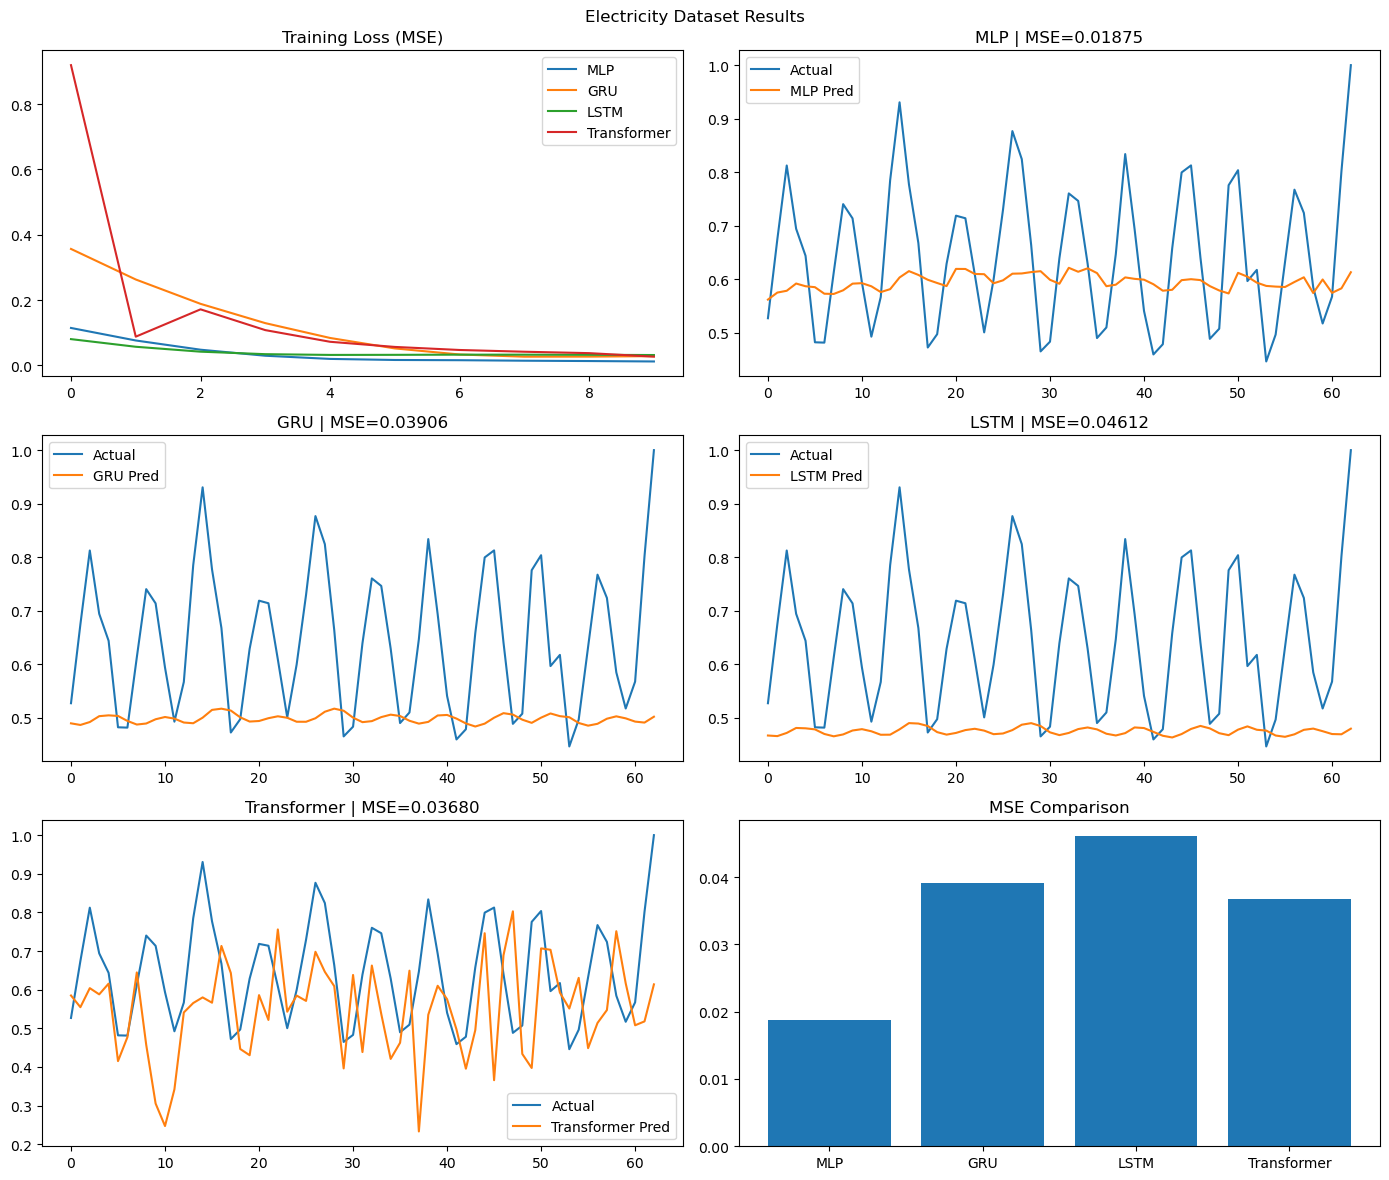

In [37]:
import matplotlib.pyplot as plt

def run_and_plot(window, title, save_path):

    train_loader = prepare_data(train_data, window)
    test_loader  = prepare_data(test_data, window)

    models = {
        "MLP": MLP(window),
        "GRU": CustomGRU(),
        "LSTM": LSTMModel(),
        "Transformer": TransformerModel(1, hidden_size, prediction_horizon, window)
    }

    losses_dict = {}
    results_dict = {}
    mse_dict = {}

    # =========================
    # TRAIN + EVALUATE
    # =========================
    for name, model in models.items():

        print(f"\nTraining: {name}")

        losses = train_model(model, train_loader)
        preds, actual, mse, mae, rmse = evaluate(model, test_loader)

        losses_dict[name] = losses
        results_dict[name] = (actual, preds)
        mse_dict[name] = mse

    # =========================
    # PLOT (LIKE YOUR FRIEND)
    # =========================
    plt.figure(figsize=(14, 12))

    # LOSS
    plt.subplot(3, 2, 1)
    for name, losses in losses_dict.items():
        plt.plot(losses, label=name)
    plt.title("Training Loss (MSE)")
    plt.legend()

    # MLP
    plt.subplot(3, 2, 2)
    actual, pred = results_dict["MLP"]
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="MLP Pred")
    plt.title(f"MLP | MSE={mse_dict['MLP']:.5f}")
    plt.legend()

    # GRU
    plt.subplot(3, 2, 3)
    actual, pred = results_dict["GRU"]
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="GRU Pred")
    plt.title(f"GRU | MSE={mse_dict['GRU']:.5f}")
    plt.legend()

    # LSTM
    plt.subplot(3, 2, 4)
    actual, pred = results_dict["LSTM"]
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="LSTM Pred")
    plt.title(f"LSTM | MSE={mse_dict['LSTM']:.5f}")
    plt.legend()

    # TRANSFORMER
    plt.subplot(3, 2, 5)
    actual, pred = results_dict["Transformer"]
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="Transformer Pred")
    plt.title(f"Transformer | MSE={mse_dict['Transformer']:.5f}")
    plt.legend()

    # RMSE BAR
    plt.subplot(3, 2, 6)
    names = list(mse_dict.keys())
    values = list(mse_dict.values())
    plt.bar(names, values)
    plt.title("MSE Comparison")

    plt.suptitle(title)
    plt.tight_layout()

    # SAVE IMAGE
    import os
    os.makedirs("results", exist_ok=True)
    plt.savefig(save_path)

    plt.show()


# ================================
# RUN FOR ELECTRICITY
# ================================

run_and_plot(
    window_size,
    "Electricity Dataset Results",
    "results/electricity_results.png"
)
